# Лабораторная работа №3. Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей

**Курс:** Технологии машинного обучения

**Цель работы:** изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

**Задание:**
1. Выбрать набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости провести удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода `train_test_split` разделить выборку на обучающую и тестовую.
4. Обучить модель ближайших соседей для произвольно заданного гиперпараметра K. Оценить качество модели с помощью подходящих для задачи метрик.
5. Произвести подбор гиперпараметра K с использованием `GridSearchCV` и `RandomizedSearchCV` и кросс-валидации, оценить качество оптимальной модели. Использовать не менее двух стратегий кросс-валидации.
6. Сравнить метрики качества исходной и оптимальной моделей.

Ссылка на постановку задания: https://github.com/ugapanyuk/courses_current/wiki/LAB_TMO__KNN

## 1. Выбор набора данных

Используется датасет **Pima Indians Diabetes Database** с платформы Kaggle
([uciml/pima-indians-diabetes-database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)).
Файл сохранён локально в `data/diabetes.csv`.

Датасет содержит медицинские показатели 768 пациенток (женщины индейского племени пима, возраст от 21 года) и
бинарный признак наличия диабета в течение 5 лет. Решается задача **бинарной классификации**.

Датасет выбран, так как:
- метод ближайших соседей чувствителен к масштабу признаков, а признаки здесь имеют очень разный масштаб
  (`DiabetesPedigreeFunction` ~ 0.1–2.4, `Insulin` ~ 0–846), что позволяет показать важность масштабирования;
- в данных есть скрытые пропуски (недопустимые нулевые значения), требующие обработки;
- объём (768 строк, 8 признаков) достаточен для кросс-валидации и быстрого подбора гиперпараметров.

**Описание столбцов:**
- `Pregnancies` — число беременностей;
- `Glucose` — концентрация глюкозы в плазме через 2 часа после перорального теста на толерантность к глюкозе;
- `BloodPressure` — диастолическое артериальное давление (мм рт. ст.);
- `SkinThickness` — толщина кожной складки трицепса (мм);
- `Insulin` — 2-часовой сывороточный инсулин (мкЕд/мл);
- `BMI` — индекс массы тела;
- `DiabetesPedigreeFunction` — функция наследственной предрасположенности к диабету;
- `Age` — возраст (лет);
- `Outcome` — целевой признак (1 — диабет, 0 — нет диабета).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV,
                                     StratifiedKFold, KFold, RepeatedStratifiedKFold, cross_val_score)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay)
from scipy.stats import randint

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

## 2. Загрузка данных и первичный анализ

In [2]:
data = pd.read_csv("data/diabetes.csv")
print("Размер набора данных:", data.shape)
data.head()

Размер набора данных: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Outcome
0    500
1    268
Name: count, dtype: int64

Доли классов:
Outcome
0    0.651
1    0.349
Name: count, dtype: float64


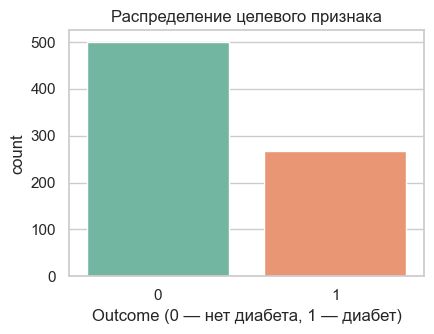

In [5]:
# Баланс классов
counts = data["Outcome"].value_counts()
print(counts)
print("\nДоли классов:")
print((counts / len(data)).round(3))

fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.countplot(x="Outcome", data=data, ax=ax, palette="Set2")
ax.set_title("Распределение целевого признака")
ax.set_xlabel("Outcome (0 — нет диабета, 1 — диабет)")
plt.tight_layout()
plt.show()

## 3. Обработка пропусков и кодирование категориальных признаков

**Категориальные признаки.** Все признаки датасета числовые, целевой признак `Outcome` уже закодирован (0/1),
поэтому кодирование категориальных признаков не требуется.

**Пропуски.** Формально пропусков (`NaN`) в файле нет, однако в столбцах `Glucose`, `BloodPressure`, `SkinThickness`,
`Insulin`, `BMI` встречаются значения `0`, которые физиологически невозможны — это скрытые пропуски.
Заменим их на `NaN` и оценим долю пропусков. Признак `Pregnancies` может быть нулевым (это корректное значение), его не трогаем.

In [6]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Количество нулей (скрытых пропусков) до обработки:")
print((data[zero_cols] == 0).sum())

data[zero_cols] = data[zero_cols].replace(0, np.nan)

missing = pd.DataFrame({"Пропусков": data.isna().sum(),
                        "Доля, %": (data.isna().mean() * 100).round(1)})
missing

Количество нулей (скрытых пропусков) до обработки:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


,Пропусков,"Доля, %"
Pregnancies,0,0.0
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


Наибольшая доля пропусков в `Insulin` (~49 %) и `SkinThickness` (~30 %), поэтому удаление строк привело бы к потере
значительной части выборки. Выбрано **заполнение медианой** (устойчива к выбросам, а распределения признаков скошены).

Чтобы избежать утечки информации из тестовой выборки, медианы вычисляются **только по обучающей выборке**:
импьютер включается в `Pipeline` и обучается вместе с моделью. Там же выполняется **масштабирование**
(`StandardScaler`), так как метод ближайших соседей основан на расстояниях.

## 4. Разделение выборки на обучающую и тестовую

In [7]:
X = data.drop(columns="Outcome")
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print("Обучающая выборка:", X_train.shape, " Тестовая выборка:", X_test.shape)
print("\nДоля класса 1 в обучающей выборке: %.3f" % y_train.mean())
print("Доля класса 1 в тестовой выборке:  %.3f" % y_test.mean())

Обучающая выборка: (576, 8)  Тестовая выборка: (192, 8)

Доля класса 1 в обучающей выборке: 0.349
Доля класса 1 в тестовой выборке:  0.349


Использован параметр `stratify=y`, чтобы доли классов в обеих выборках совпадали с исходными (набор несбалансирован: ~35 % класса 1).

## 5. Обучение модели ближайших соседей с произвольным K

Возьмём произвольное значение **K = 5** (значение по умолчанию). Для наглядности сначала сравним модель
без масштабирования и с масштабированием.

Так как классы несбалансированы, наряду с `accuracy` используем `balanced accuracy`, `precision`, `recall`, `F1` и `ROC AUC`.

In [8]:
def make_pipeline(k=5, **knn_params):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, **knn_params)),
    ])

def evaluate(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return pd.Series({
        "Accuracy": accuracy_score(y_te, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "ROC AUC": roc_auc_score(y_te, y_proba),
    }, name=name)

# Без масштабирования (только импьютер)
knn_noscale = Pipeline([("imputer", SimpleImputer(strategy="median")),
                        ("knn", KNeighborsClassifier(n_neighbors=5))]).fit(X_train, y_train)
# С масштабированием
knn_base = make_pipeline(k=5).fit(X_train, y_train)

res_scale = pd.concat([evaluate(knn_noscale, X_test, y_test, "K=5, без масштабирования"),
                       evaluate(knn_base, X_test, y_test, "K=5, со StandardScaler")], axis=1).T
res_scale.round(4)

,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC
"K=5, без масштабирования",0.6719,0.6233,0.5345,0.4627,0.496,0.7084
"K=5, со StandardScaler",0.7344,0.6921,0.6379,0.5522,0.592,0.7761


                 precision    recall  f1-score   support

Нет диабета (0)       0.78      0.83      0.80       125
     Диабет (1)       0.64      0.55      0.59        67

       accuracy                           0.73       192
      macro avg       0.71      0.69      0.70       192
   weighted avg       0.73      0.73      0.73       192



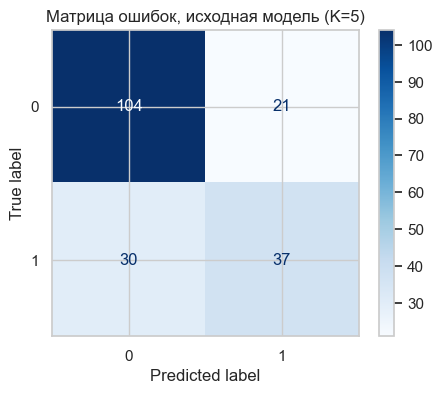

In [9]:
y_pred_base = knn_base.predict(X_test)
print(classification_report(y_test, y_pred_base, target_names=["Нет диабета (0)", "Диабет (1)"]))

fig, ax = plt.subplots(figsize=(4.8, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, display_labels=["0", "1"], cmap="Blues", ax=ax)
ax.set_title("Матрица ошибок, исходная модель (K=5)")
plt.tight_layout()
plt.show()

Масштабирование признаков повышает качество модели, поэтому далее используется конвейер `SimpleImputer → StandardScaler → KNeighborsClassifier`.

## 6. Подбор гиперпараметра K

Подбор выполняется по обучающей выборке с помощью `GridSearchCV` (полный перебор) и `RandomizedSearchCV`
(случайный перебор) для диапазона `K = 1…50`. Метрика для выбора модели — `F1` по классу 1 (набор несбалансирован,
важно находить больных пациентов и не терять точность).

Используются **три стратегии кросс-валидации**:
1. `StratifiedKFold(n_splits=5)` — с сохранением долей классов в блоках;
2. `KFold(n_splits=5, shuffle=True)` — без стратификации;
3. `RepeatedStratifiedKFold(n_splits=5, n_repeats=3)` — повторная стратифицированная (более устойчивая оценка).

In [10]:
cv_strategies = {
    "StratifiedKFold(5)": StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    "KFold(5)": KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    "RepeatedStratifiedKFold(5x3)": RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE),
}
SCORING = "f1"

pipe = make_pipeline()
param_grid = {"knn__n_neighbors": list(range(1, 51))}

### 6.1. GridSearchCV

In [11]:
grid_results = {}
rows = []
for cv_name, cv in cv_strategies.items():
    gs = GridSearchCV(pipe, param_grid, cv=cv, scoring=SCORING, n_jobs=-1)
    gs.fit(X_train, y_train)
    grid_results[cv_name] = gs
    rows.append({"CV-стратегия": cv_name, "Лучший K": gs.best_params_["knn__n_neighbors"],
                 f"CV {SCORING}": round(gs.best_score_, 4)})
pd.DataFrame(rows)

,CV-стратегия,Лучший K,CV f1
0,StratifiedKFold(5),15,0.6458
1,KFold(5),13,0.6452
2,RepeatedStratifiedKFold(5x3),13,0.6350


### 6.2. RandomizedSearchCV

In [12]:
param_dist = {"knn__n_neighbors": randint(1, 51)}

rand_results = {}
rows = []
for cv_name, cv in cv_strategies.items():
    rs = RandomizedSearchCV(pipe, param_dist, n_iter=20, cv=cv, scoring=SCORING,
                            n_jobs=-1, random_state=RANDOM_STATE)
    rs.fit(X_train, y_train)
    rand_results[cv_name] = rs
    rows.append({"CV-стратегия": cv_name, "Лучший K": rs.best_params_["knn__n_neighbors"],
                 f"CV {SCORING}": round(rs.best_score_, 4)})
pd.DataFrame(rows)

,CV-стратегия,Лучший K,CV f1
0,StratifiedKFold(5),15,0.6458
1,KFold(5),11,0.6357
2,RepeatedStratifiedKFold(5x3),11,0.6307


### 6.3. Зависимость качества от K

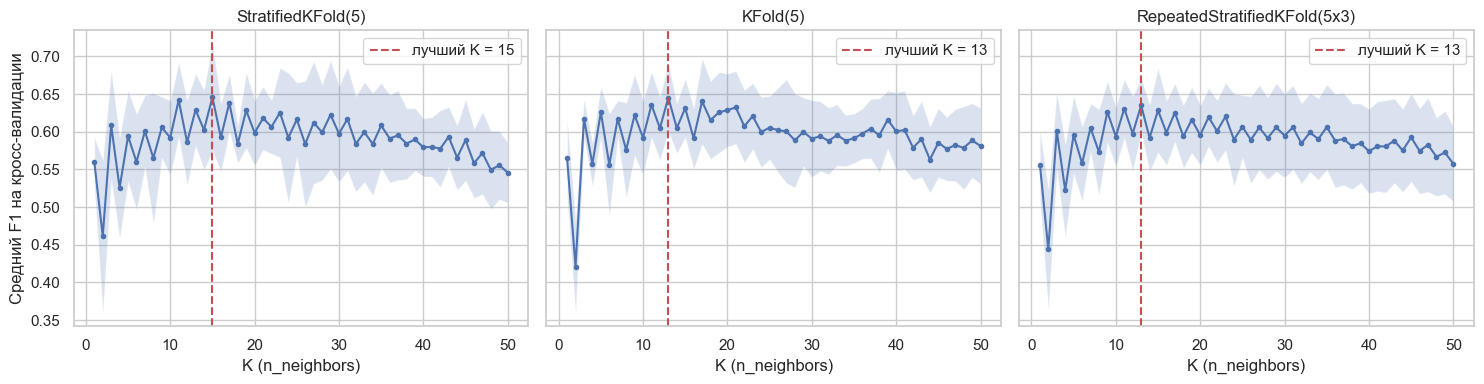

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (cv_name, gs) in zip(axes, grid_results.items()):
    r = gs.cv_results_
    ks = [p["knn__n_neighbors"] for p in r["params"]]
    ax.plot(ks, r["mean_test_score"], marker="o", ms=3)
    ax.fill_between(ks, r["mean_test_score"] - r["std_test_score"],
                    r["mean_test_score"] + r["std_test_score"], alpha=0.2)
    ax.axvline(gs.best_params_["knn__n_neighbors"], color="r", ls="--",
               label="лучший K = %d" % gs.best_params_["knn__n_neighbors"])
    ax.set_title(cv_name)
    ax.set_xlabel("K (n_neighbors)")
    ax.legend()
axes[0].set_ylabel("Средний F1 на кросс-валидации")
plt.tight_layout()
plt.show()

Зависимость качества от K зашумлена: при малых K модель переобучается, при слишком больших — недообучается,
а сам максимум довольно пологий. Разные стратегии кросс-валидации дают близкие, но не обязательно одинаковые K.

## 7. Оценка оптимальной модели на тестовой выборке

В качестве оптимальной берётся модель с лучшим средним значением F1 на кросс-валидации среди результатов `GridSearchCV`
(`GridSearchCV` перебирает все K, поэтому находит глобальный максимум сетки, `refit=True` автоматически переобучает модель на всей обучающей выборке).
Результаты остальных стратегий и `RandomizedSearchCV` оцениваются на тесте для сравнения.

In [14]:
all_models = {}
for cv_name, gs in grid_results.items():
    all_models["Grid, " + cv_name] = gs
for cv_name, rs in rand_results.items():
    all_models["Random, " + cv_name] = rs

rows = [evaluate(knn_base, X_test, y_test, "Исходная (K=5)")]
for name, est in all_models.items():
    k = est.best_params_["knn__n_neighbors"]
    rows.append(evaluate(est.best_estimator_, X_test, y_test, "%s (K=%d)" % (name, k)))
compare_all = pd.DataFrame(rows)
compare_all.round(4)

,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC
Исходная (K=5),0.7344,0.6921,0.6379,0.5522,0.5920,0.7761
"Grid, StratifiedKFold(5) (K=15)",0.7240,0.6772,0.6250,0.5224,0.5691,0.8005
"Grid, KFold(5) (K=13)",0.7292,0.6847,0.6316,0.5373,0.5806,0.7923
"Grid, RepeatedStratifiedKFold(5x3) (K=13)",0.7292,0.6847,0.6316,0.5373,0.5806,0.7923
"Random, StratifiedKFold(5) (K=15)",0.7240,0.6772,0.6250,0.5224,0.5691,0.8005
"Random, KFold(5) (K=11)",0.7344,0.6887,0.6429,0.5373,0.5854,0.7943
"Random, RepeatedStratifiedKFold(5x3) (K=11)",0.7344,0.6887,0.6429,0.5373,0.5854,0.7943


In [15]:
# Выбор оптимальной модели: лучший CV-результат среди GridSearchCV
best_name = max(grid_results, key=lambda n: grid_results[n].best_score_)
best_search = grid_results[best_name]
best_k = best_search.best_params_["knn__n_neighbors"]
best_model = best_search.best_estimator_
print("Оптимальная модель: GridSearchCV,", best_name)
print("Оптимальное K =", best_k, "| CV F1 = %.4f" % best_search.best_score_)

Оптимальная модель: GridSearchCV, StratifiedKFold(5)
Оптимальное K = 15 | CV F1 = 0.6458


## 8. Сравнение исходной и оптимальной моделей

In [16]:
cmp = pd.concat([evaluate(knn_base, X_test, y_test, "Исходная (K=5)"),
                 evaluate(best_model, X_test, y_test, "Оптимальная (K=%d)" % best_k)], axis=1).T
cmp.loc["Изменение"] = cmp.iloc[1] - cmp.iloc[0]
cmp.round(4)

,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC
Исходная (K=5),0.7344,0.6921,0.6379,0.5522,0.5920,0.7761
Оптимальная (K=15),0.7240,0.6772,0.6250,0.5224,0.5691,0.8005
Изменение,-0.0104,-0.0149,-0.0129,-0.0299,-0.0229,0.0244


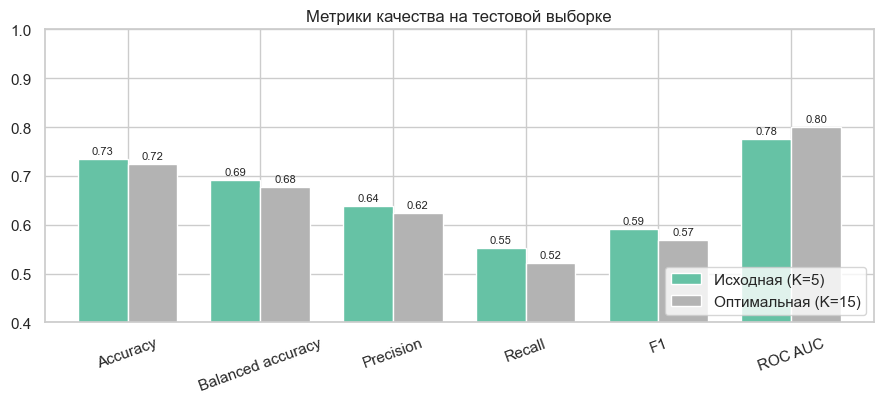

In [17]:
metrics = ["Accuracy", "Balanced accuracy", "Precision", "Recall", "F1", "ROC AUC"]
plot_df = cmp.iloc[:2][metrics].T
ax = plot_df.plot(kind="bar", figsize=(9, 4.2), rot=20, colormap="Set2", width=0.75)
ax.set_ylim(0.4, 1.0)
ax.set_title("Метрики качества на тестовой выборке")
ax.legend(loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

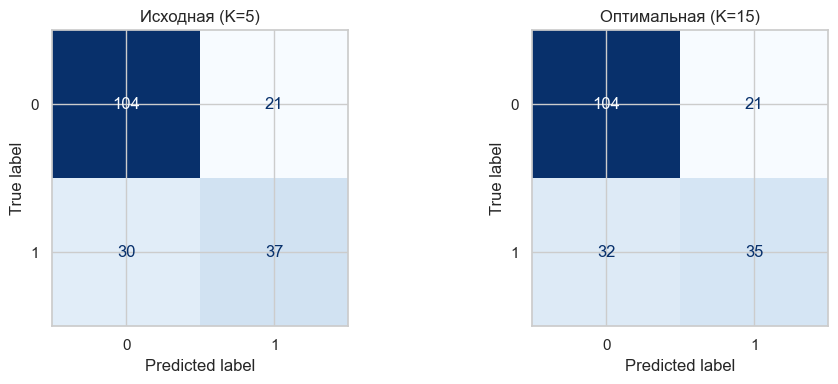

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (title, model) in zip(axes, [("Исходная (K=5)", knn_base),
                                      ("Оптимальная (K=%d)" % best_k, best_model)]):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["0", "1"],
                                          cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

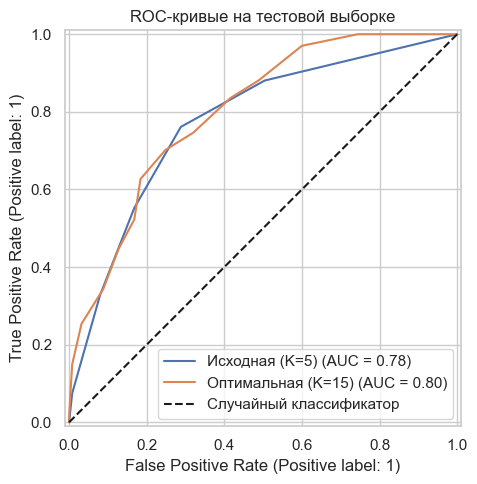

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(knn_base, X_test, y_test, name="Исходная (K=5)", ax=ax)
RocCurveDisplay.from_estimator(best_model, X_test, y_test, name="Оптимальная (K=%d)" % best_k, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Случайный классификатор")
ax.set_title("ROC-кривые на тестовой выборке")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# Дополнительная проверка: обе модели на одной и той же стратифицированной кросс-валидации по всей обучающей выборке
cv_check = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=1)
for name, model in [("Исходная (K=5)", make_pipeline(5)), ("Оптимальная (K=%d)" % best_k, make_pipeline(best_k))]:
    s = cross_val_score(model, X_train, y_train, cv=cv_check, scoring="f1", n_jobs=-1)
    print("%-22s F1 на CV: %.4f ± %.4f" % (name, s.mean(), s.std()))

Исходная (K=5)         F1 на CV: 0.6309 ± 0.0627
Оптимальная (K=15)     F1 на CV: 0.6449 ± 0.0438


## 9. Выводы

- Выбран датасет Pima Indians Diabetes (Kaggle), решена задача бинарной классификации. Скрытые пропуски (нули в
  `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) заменены на `NaN` и заполнены медианой, вычисленной по обучающей выборке
  (в составе `Pipeline`, без утечки данных). Категориальных признаков нет, кодирование не требовалось.
- Выборка разделена методом `train_test_split` в пропорции 75/25 со стратификацией по целевому признаку.
- Масштабирование существенно для метода ближайших соседей, так как он основан на расстояниях, а признаки имеют разный масштаб.
- Подбор K выполнен с помощью `GridSearchCV` и `RandomizedSearchCV` на трёх стратегиях кросс-валидации
  (`StratifiedKFold`, `KFold`, `RepeatedStratifiedKFold`). Оптимальное K определяется зашумлённо: разные стратегии дают различные, но близкие по качеству значения.
- Сравнение исходной (K=5) и оптимальной моделей выполнено по метрикам accuracy, balanced accuracy, precision, recall, F1 и ROC AUC
  на отложенной тестовой выборке.
- Результат сравнения: подбор K (K = 5 → K = 15) улучшил качество на кросс-валидации (F1: 0.631 → 0.645, при этом разброс между блоками снизился
  с 0.063 до 0.044) и повысил ROC AUC на тесте (0.776 → 0.801), то есть модель лучше ранжирует пациентов по риску диабета и стала стабильнее.
  Однако при пороге 0.5 на тестовой выборке (192 объекта) F1 и recall оказались немного ниже (F1: 0.592 → 0.569, recall: 0.552 → 0.522).
  Разница в 1–2 объекта тестовой выборки лежит в пределах статистического шума, поэтому нельзя утверждать, что оптимальная модель однозначно лучше по всем метрикам:
  K, выбранный по кросс-валидации, не гарантирует выигрыша на конкретном разбиении.